In [9]:
#B. data pre-processing

In [7]:
import pandas as pd

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3-Marketing-Dataset.csv'

df = pd.read_csv(file_path)

mask_unknown = (df == 'unknown').any(axis=1)
mask_question = (df == '?').any(axis=1)

mask_missing_like = mask_unknown | mask_question

cleaned_df = df[~mask_missing_like].copy()

print(f"Number of rows in original dataset: {df.shape[0]}")
print(f"Number of rows contain missing values: {mask_missing_like.sum()}")
print(f"Number of rows after preprocessing: {cleaned_df.shape[0]}")

cleaned_df.to_csv('Assignment3 Data-PreProcessing.csv', index=False)

Number of rows in original dataset: 26360
Number of rows contain missing values: 9105
Number of rows after preprocessing: 17255


In [ ]:
#Figure 3. Missing-like values summary across attributes

In [15]:
import pandas as pd

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3-Marketing-Dataset.csv'

df = pd.read_csv(file_path)

missing_like = df.isin(['unknown', '?'])
missing_count = missing_like.sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Attribute': missing_count.index,
    'Missing Count': missing_count.values,
    'Missing Percentage (%)': missing_percentage.round(2).values
})

print(missing_summary)

         Attribute  Missing Count  Missing Percentage (%)
0           row ID              0                    0.00
1              age              0                    0.00
2              job            212                    0.80
3          marital             51                    0.19
4        education           1080                    4.10
5          default           5551                   21.06
6          housing            647                    2.45
7             loan            647                    2.45
8          contact              0                    0.00
9            month              0                    0.00
10     day_of_week              0                    0.00
11        duration              0                    0.00
12        campaign              0                    0.00
13           pdays           1273                    4.83
14        previous              0                    0.00
15        poutcome              0                    0.00
16    emp.var.

In [2]:
# B.3 Drop rowID and categorical encoding

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3 Data-PreProcessing.csv'
df = pd.read_csv(file_path)

print(f"{df.shape}")
df.head()

if 'row ID' in df.columns:
    df.drop(columns=['row ID'], inplace=True)
    print("Successfully drop 'row ID'")
else:
    print("Error to drop 'row ID'")

categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'state'
]

label_encoders = {}

for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
        print(f"Successfully encoding '{col}'")
    else:
        print(f"Error to encoding '{col}'")

print(f"{df.shape}")
df.head()

(17255, 23)
Successfully drop 'row ID'
Successfully encoding 'job'
Successfully encoding 'marital'
Successfully encoding 'education'
Successfully encoding 'default'
Successfully encoding 'housing'
Successfully encoding 'loan'
Successfully encoding 'contact'
Successfully encoding 'month'
Successfully encoding 'day_of_week'
Successfully encoding 'poutcome'
Successfully encoding 'state'
(17255, 22)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,state,subscribed
0,56,3,1,0,0,0,0,1,6,1,...,999,0,1,1.1,93.994,-36.4,4.857,5191.0,6,0
1,56,7,1,3,0,0,1,1,6,1,...,999,0,1,1.1,93.994,-36.4,4.857,5191.0,2,0
2,59,0,1,5,0,0,0,1,6,1,...,999,0,1,1.1,93.994,-36.4,4.857,5191.0,1,0
3,24,9,2,5,0,1,0,1,6,1,...,999,0,1,1.1,93.994,-36.4,4.857,5191.0,2,0
4,25,7,2,3,0,1,0,1,6,1,...,999,0,1,1.1,93.994,-36.4,4.857,5191.0,4,0


In [10]:
save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver1.csv'
df.to_csv(save_path, index=False)

In [13]:
# B.4 Data transformation for 'campaign' & 'previous'

In [15]:
import pandas as pd
import numpy as np

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver1.csv'
df = pd.read_csv(file_path)

columns_to_transform = ['campaign', 'previous']

for col in columns_to_transform:
    if col in df.columns:
        df[col] = np.log1p(df[col])
        print(f"Successfully data transformation '{col}'")
    else:
        print(f"Error to data transformation '{col}'")

save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver2(transformation).csv'
df.to_csv(save_path, index=False)

df[columns_to_transform].head()

Successfully data transformation 'campaign'
Successfully data transformation 'previous'


,campaign,previous
0,0.693147,0.0
1,0.693147,0.0
2,0.693147,0.0
3,0.693147,0.0
4,0.693147,0.0


In [17]:
# B.5 Normalization

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver2(transformation).csv'
df = pd.read_csv(file_path)

numerical_cols_to_scale = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

scaler = StandardScaler()
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print(f"Successfully Normalization!")

save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver3(Normalization).csv'
df.to_csv(save_path, index=False)

Successfully Normalization!


In [21]:
# B.6 Linear, Rank Correlation

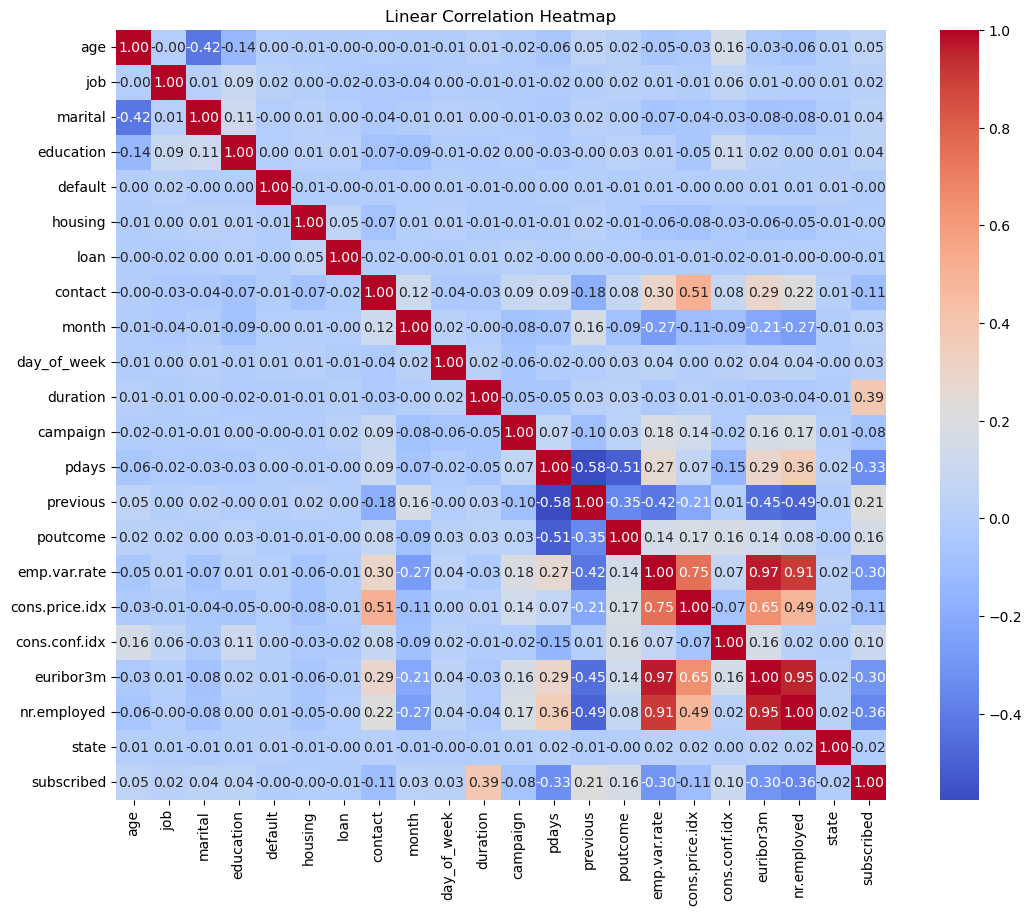

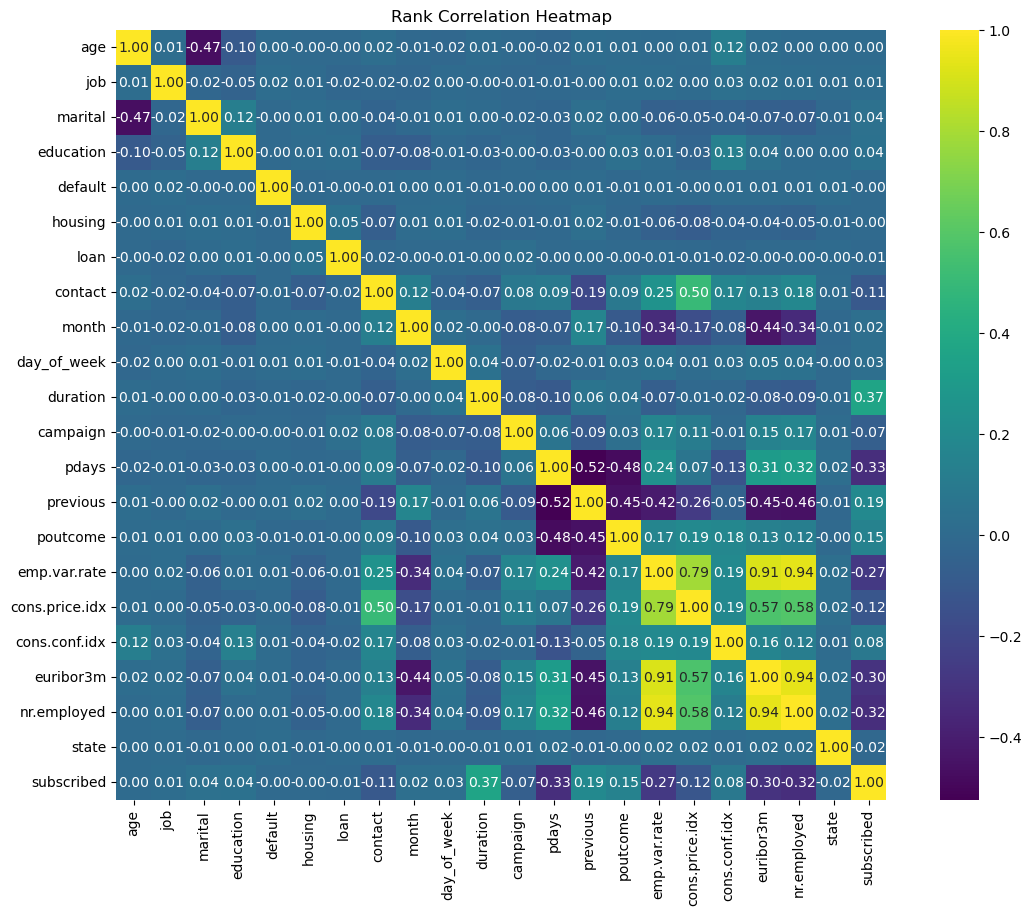

,Feature,Pearson_Correlation_Subscribed,Spearman_Correlation_Subscribed
0,subscribed,1.000000,1.000000
1,duration,0.385316,0.367044
2,previous,0.213487,0.192629
3,poutcome,0.158449,0.147957
4,cons.conf.idx,0.104441,0.083617
5,age,0.049359,0.042311
6,education,0.036448,0.037695
7,marital,0.036262,0.025898
8,month,0.029962,0.024998
9,day_of_week,0.025340,0.013561


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver3(Normalization).csv'
df = pd.read_csv(file_path)

# Linear Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(method='pearson'), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Linear Correlation Heatmap')
plt.show()

# Rank Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(method='spearman'), annot=True, fmt='.2f', cmap='viridis', square=True)
plt.title('Rank Correlation Heatmap')
plt.show()

target_corr_pearson = df.corr(method='pearson')['subscribed'].sort_values(ascending=False)
target_corr_spearman = df.corr(method='spearman')['subscribed'].sort_values(ascending=False)

correlation_results = pd.DataFrame({
    'Feature': target_corr_pearson.index,
    'Pearson_Correlation_Subscribed': target_corr_pearson.values,
    'Spearman_Correlation_Subscribed': target_corr_spearman.values
})

save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver4(Correlation).csv'
correlation_results.to_csv(save_path, index=False)

correlation_results

In [2]:
# C.1 Outlier Detection & Handling

In [10]:
import pandas as pd

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver3(Normalization).csv'
df = pd.read_csv(file_path)

numerical_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower=lower, upper=upper)

df[numerical_cols].describe()

save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_C.1.csv'
df.to_csv(save_path, index=False)

In [ ]:
#slide by slide boxflot , figure 15,16

/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_10737/3043146276.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Stage', y=col, palette='Set2')


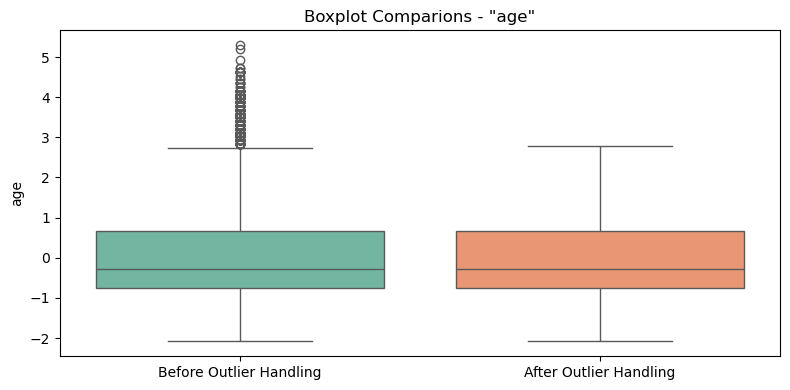

/var/folders/2y/2ygb5kn16j1fsmtqrr3w992h0000gn/T/ipykernel_10737/3043146276.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Stage', y=col, palette='Set2')


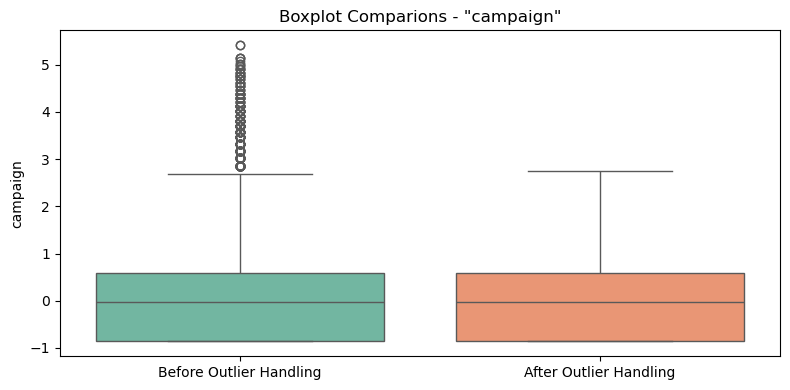

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_Ver3(Normalization).csv'
df_original = pd.read_csv(file_path)

for col in ['age', 'campaign']:
    temp_df = pd.DataFrame({
        col: pd.concat([df_original[col], df[col]]).values,
        'Stage': ['Before Outlier Handling'] * len(df_original) + ['After Outlier Handling'] * len(df)
    })

    plt.figure(figsize=(8, 4))
    sns.boxplot(data=temp_df, x='Stage', y=col, palette='Set2')
    plt.title(f'Boxplot Comparions - "{col}"')
    plt.ylabel(col)
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

In [22]:
# C.3 Data Partitioning Strategy

In [26]:
from sklearn.model_selection import train_test_split
import pandas as pd

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3-Data_preprocessing_C.1.csv'
df = pd.read_csv(file_path)

target = 'subscribed'

train_df, temp_df = train_test_split(
    df, 
    test_size=0.30, 
    stratify=df[target], 
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df, 
    test_size=0.50, 
    stratify=temp_df[target], 
    random_state=42
)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

train_df.to_csv('Assignment3_Train.csv', index=False)
val_df.to_csv('Assignment3_Validation.csv', index=False)
test_df.to_csv('Assignment3_Test.csv', index=False)

Train shape: (12078, 22)
Validation shape: (2588, 22)
Test shape: (2589, 22)


In [28]:
# C.4 Unbalanced Data Handling
# Random Oversampling

In [2]:
from imblearn.over_sampling import RandomOverSampler
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train.csv'
df_train = pd.read_csv(file_path)

X = df_train.drop(columns=['subscribed'])
y = df_train['subscribed']

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

resampled_df = pd.concat(
    [pd.DataFrame(X_resampled, columns=X.columns), pd.Series(y_resampled, name='subscribed')],
    axis=1
)
save_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'

resampled_df.to_csv(save_path, index=False)

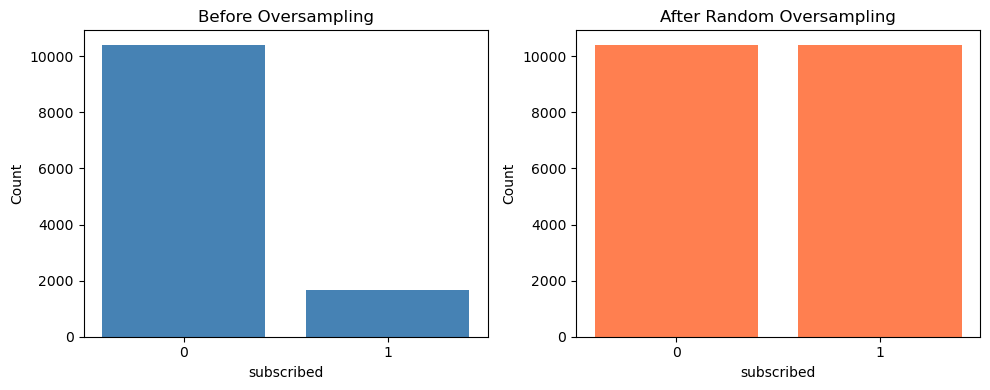

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(Counter(y).keys(), Counter(y).values(), color='steelblue')
ax[0].set_title('Before Oversampling')
ax[0].set_xticks([0, 1])
ax[0].set_xlabel('subscribed')
ax[0].set_ylabel('Count')

ax[1].bar(Counter(y_resampled).keys(), Counter(y_resampled).values(), color='coral')
ax[1].set_title('After Random Oversampling')
ax[1].set_xticks([0, 1])
ax[1].set_xlabel('subscribed')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [38]:
# D.1 Decision Trees

Best parameters: {'max_depth': 10, 'min_samples_split': 2}
F1-score: 0.5901287553648069
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2230
           1       0.48      0.77      0.59       358

    accuracy                           0.85      2588
   macro avg       0.72      0.82      0.75      2588
weighted avg       0.89      0.85      0.87      2588



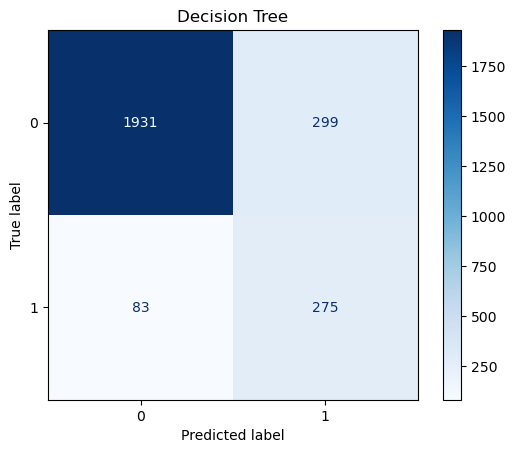

In [6]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("Assignment3_Train_Resampled.csv")
X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

val_df = pd.read_csv("Assignment3_Validation.csv")
X_val = val_df.drop(columns=['subscribed'])
y_val = val_df['subscribed']

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_val)

print("Best parameters:", grid_search.best_params_)
print("F1-score:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Decision Tree")
plt.show()

In [8]:
# D.2 K-Nearest Neighbours (KNN)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
F1-score: 0.5083612040133779
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      2230
           1       0.42      0.64      0.51       358

    accuracy                           0.83      2588
   macro avg       0.68      0.75      0.70      2588
weighted avg       0.87      0.83      0.84      2588



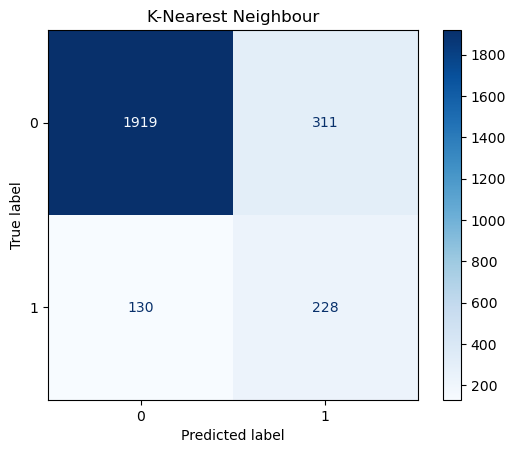

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("Assignment3_Train_Resampled.csv")
X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

val_df = pd.read_csv("Assignment3_Validation.csv")
X_val = val_df.drop(columns=['subscribed'])
y_val = val_df['subscribed']

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_val)

print("Best parameters:", grid_search.best_params_)
print("F1-score:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("K-Nearest Neighbour")
plt.show()

In [13]:
# D.3 Random Forest

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 100}
F1-score: 0.6429447852760736
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2230
           1       0.57      0.73      0.64       358

    accuracy                           0.89      2588
   macro avg       0.76      0.82      0.79      2588
weighted avg       0.90      0.89      0.89      2588



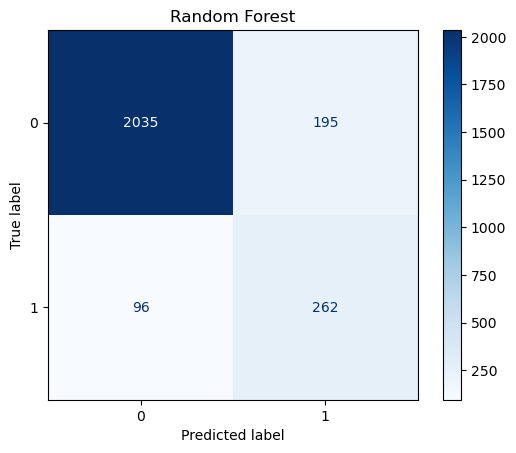

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("Assignment3_Train_Resampled.csv")
X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

val_df = pd.read_csv("Assignment3_Validation.csv")
X_val = val_df.drop(columns=['subscribed'])
y_val = val_df['subscribed']

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_val)

print("Best parameters:", grid_search.best_params_)
print("F1-score:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Random Forest")
plt.show()

In [19]:
# D.4 Support Vector Machine (SVM)

Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
F1-score: 0.3508771929824561
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2230
           1       0.47      0.28      0.35       358

    accuracy                           0.86      2588
   macro avg       0.68      0.61      0.64      2588
weighted avg       0.83      0.86      0.84      2588



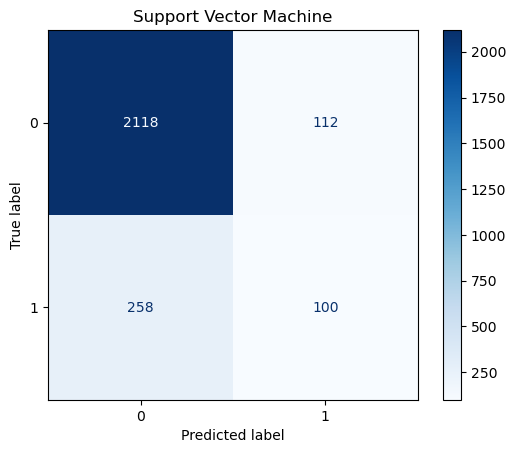

In [4]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

train_file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
val_file_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Validation.csv'

train_df = pd.read_csv(train_file_path)
X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

val_df = pd.read_csv(val_file_path)
X_val = val_df.drop(columns=['subscribed'])
y_val = val_df['subscribed']

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

svm = SVC()
grid_search = GridSearchCV(svm, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_val)

print("Best parameters:", grid_search.best_params_)
print("F1-score:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Support Vector Machine")
plt.show()

In [6]:
# D.5 Nerual Network (NN)

Best parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 50), 'learning_rate_init': 0.01}
F1-score: 0.5586776859504132
              precision    recall  f1-score   support

           0       0.99      0.77      0.87      2230
           1       0.40      0.94      0.56       358

    accuracy                           0.79      2588
   macro avg       0.69      0.86      0.71      2588
weighted avg       0.91      0.79      0.82      2588



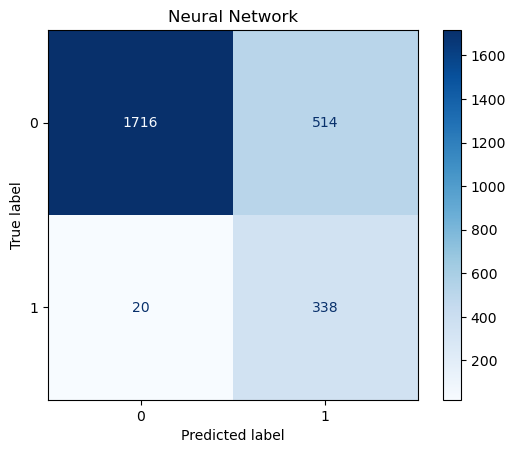

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv("Assignment3_Train_Resampled.csv")
X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']
val_df = pd.read_csv("Assignment3_Validation.csv")
X_val = val_df.drop(columns=['subscribed'])
y_val = val_df['subscribed']

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}

mlp = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True, 
                   validation_fraction=0.1, n_iter_no_change=10, tol=1e-4)
grid_search = GridSearchCV(mlp, param_grid, scoring='f1', cv=5)
grid_search.fit(X_train, y_train)

best_mlp = grid_search.best_estimator_
y_pred = best_mlp.predict(X_val)
print("Best parameters:", grid_search.best_params_)
print("F1-score:", f1_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Neural Network")
plt.show()

In [2]:
# D.6 Ensemble Model 

In [4]:
import pandas as pd
import numpy as np

rf_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_RF.csv'
nn_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_NN.csv'
knn_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_KNN.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Ensemble_Model.csv'

rf_df = pd.read_csv(rf_path)
nn_df = pd.read_csv(nn_path)
knn_df = pd.read_csv(knn_path)

weights = [0.3, 0.6, 0.1]

ensemble_pred = (
    rf_df['Prediction-subscribed'] * weights[0] +
    nn_df['Prediction-subscribed'] * weights[1] +
    knn_df['Prediction-subscribed'] * weights[2]
)

optimal_threshold = 0.45
final_pred = (ensemble_pred >= optimal_threshold).astype(int)

submission = pd.DataFrame({
    'row ID': rf_df['row ID'],
    'Prediction-subscribed': final_pred
})

submission.to_csv(output_path, index=False)

In [ ]:
# unknown-dataset PreProcessing

In [6]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3-Unknown-Dataset.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Unknown_Preprocessed.csv'

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

row_ids = unknown_df['row ID']
unknown_df = unknown_df.drop('row ID', axis=1)

print("Train Data Shape:", train_df.shape)
print("Unknown Data Shape:", unknown_df.shape)

label_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
              'contact', 'month', 'day_of_week', 'poutcome', 'state']

for col in label_cols:
    le = LabelEncoder()

    train_df[col] = train_df[col].astype(str).fillna('unknown')
    unknown_df[col] = unknown_df[col].astype(str).fillna('unknown')
    combined_values = pd.concat([train_df[col], unknown_df[col]]).unique()
    le.fit(combined_values)
    
    unknown_df[col] = unknown_df[col].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1)
print("Successfully Label Encoding")

log_cols = ['campaign', 'previous']

for col in log_cols:
    unknown_df[col] = unknown_df[col].replace('?', np.nan).astype(float)
    unknown_df[col] = np.log1p(unknown_df[col])

print("Successfully Log Transformation")

numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 
                'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for col in numeric_cols:
    unknown_df[col] = unknown_df[col].replace('?', np.nan).astype(float)

unknown_df[numeric_cols] = unknown_df[numeric_cols].fillna(unknown_df[numeric_cols].mean())

scaler = StandardScaler()
scaler.fit(train_df[numeric_cols])

unknown_df[numeric_cols] = scaler.transform(unknown_df[numeric_cols])

print("Successfully Standard Scaling")

unknown_df['row ID'] = row_ids
cols = ['row ID'] + [col for col in unknown_df.columns if col != 'row ID']
unknown_df = unknown_df[cols]

unknown_df.to_csv(output_path, index=False)

Train Data Shape: (20812, 22)
Unknown Data Shape: (6590, 21)
Successfully Label Encoding
Successfully Log Transformation
Successfully Standard Scaling


In [8]:
# F Kaggle Submission - Random Forest

Threshold: 0.35 - Positive Rate: 0.30
best threshold: 0.35


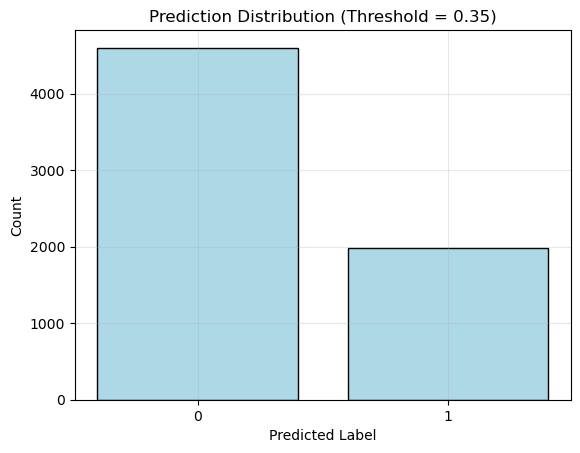

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3_Unknown_Preprocessed.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_RF.csv'

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

row_ids = unknown_df['row ID']
X_unknown = unknown_df.drop(columns=['row ID'])

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    max_features='sqrt',
    random_state=42
)

rf_model.fit(X_resampled, y_resampled)
y_proba = rf_model.predict_proba(X_unknown)[:, 1]
optimal_threshold = 0.5
best_score = -np.inf

for threshold in np.arange(0.3, 0.71, 0.05):
    y_pred = (y_proba >= threshold).astype(int)
    positive_rate = y_pred.sum() / len(y_pred)
    
    if 0.1 <= positive_rate <= 0.4:
        print(f"Threshold: {threshold:.2f} - Positive Rate: {positive_rate:.2f}")
        optimal_threshold = threshold
        break

print(f"best threshold: {optimal_threshold}")
y_pred_final = (y_proba >= optimal_threshold).astype(int)

plt.hist(y_pred_final, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='lightblue', edgecolor='black')
plt.xticks([0, 1])
plt.title(f"Prediction Distribution (Threshold = {optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

submission = pd.DataFrame({
    'row ID': row_ids,
    'Prediction-subscribed': y_pred_final
})
submission.to_csv(output_path, index=False)

In [ ]:
# F Kaggle Submission - Decision Trees

Threshold: 0.30 - Positive Rate: 0.14
best threshold: 0.3


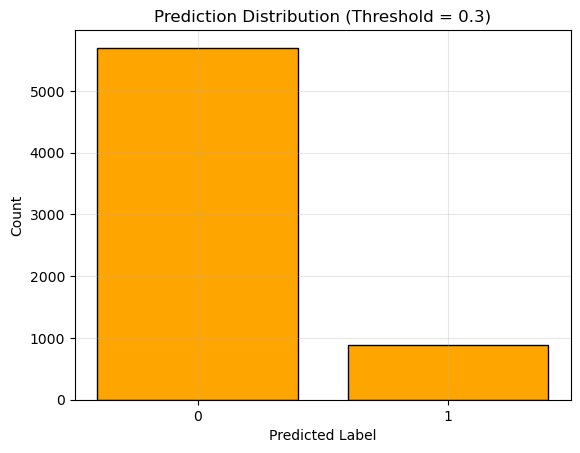

In [12]:
train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3_Unknown_Preprocessed.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_DT.csv'

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

row_ids = unknown_df['row ID']
X_unknown = unknown_df.drop(columns=['row ID'])

smote = SMOTE(sampling_strategy='minority', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

dt_model = DecisionTreeClassifier(
    max_depth=15,  
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_resampled, y_resampled)
y_proba = dt_model.predict_proba(X_unknown)[:, 1]
optimal_threshold = 0.5
best_score = -np.inf

for threshold in np.arange(0.3, 0.71, 0.05):
    y_pred = (y_proba >= threshold).astype(int)
    positive_rate = y_pred.sum() / len(y_pred)
    
    if 0.1 <= positive_rate <= 0.4:
        print(f"Threshold: {threshold:.2f} - Positive Rate: {positive_rate:.2f}")
        optimal_threshold = threshold
        break

print(f"best threshold: {optimal_threshold}")

y_pred_final = (y_proba >= optimal_threshold).astype(int)

plt.hist(y_pred_final, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='orange', edgecolor='black')
plt.xticks([0, 1])
plt.title(f"Prediction Distribution (Threshold = {optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

submission = pd.DataFrame({
    'row ID': row_ids,
    'Prediction-subscribed': y_pred_final
})

submission.to_csv(output_path, index=False)

In [ ]:
# F Kaggle Submission - Neural Network

Threshold: 0.20 - Positive Rate: 0.15
Best Threshold: 0.2


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


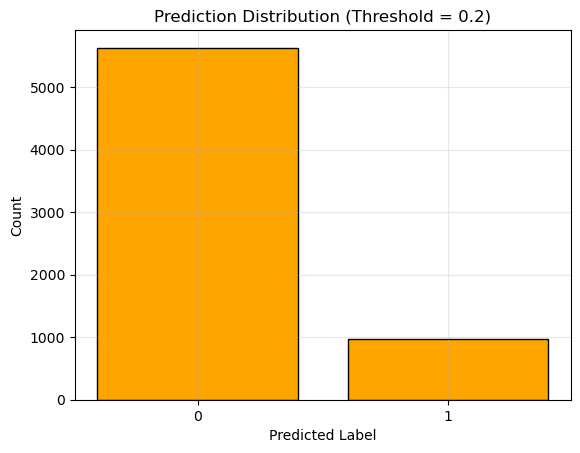

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from collections import Counter

train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3_Unknown_Preprocessed.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_NN.csv'

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

row_ids = unknown_df['row ID']
X_unknown = unknown_df.drop(columns=['row ID'])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_unknown_scaled = scaler.transform(X_unknown)

class_counts = Counter(y_train)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)
rf_proba = rf_model.predict_proba(X_unknown_scaled)[:, 1]

nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=0.0001,
    max_iter=600,
    learning_rate_init=0.00005,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)
nn_proba = nn_model.predict_proba(X_unknown_scaled)[:, 1]
ensemble_proba = (rf_proba + nn_proba) / 2
optimal_threshold = 0.1

for threshold in np.arange(0.05, 0.41, 0.05):
    y_pred = (ensemble_proba >= threshold).astype(int)
    positive_rate = y_pred.sum() / len(y_pred)
    
    if 0.1 <= positive_rate <= 0.25:
        print(f"Threshold: {threshold:.2f} - Positive Rate: {positive_rate:.2f}")
        optimal_threshold = threshold
        break

print(f"Best Threshold: {optimal_threshold}")
y_pred_final = (ensemble_proba >= optimal_threshold).astype(int)

plt.hist(y_pred_final, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='orange', edgecolor='black')
plt.xticks([0, 1])
plt.title(f"Prediction Distribution (Threshold = {optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

submission = pd.DataFrame({
    'row ID': row_ids,
    'Prediction-subscribed': y_pred_final
})

submission.to_csv(output_path, index=False)

In [ ]:
# F Kaggle Submission - K-Nearest Neighbor

Best Threshold: 0.1


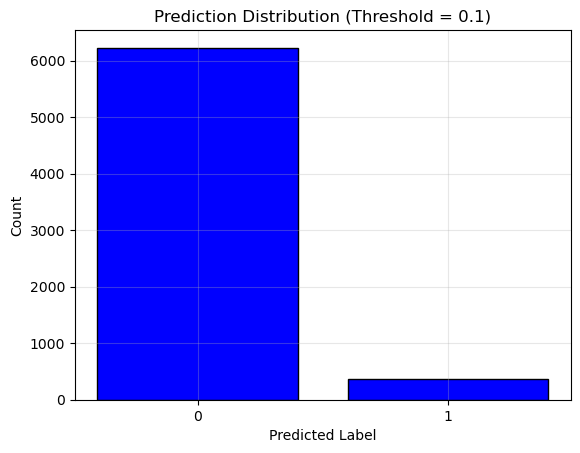

In [16]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
from collections import Counter

train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3_Unknown_Preprocessed.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_KNN.csv'

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

row_ids = unknown_df['row ID']
X_unknown = unknown_df.drop(columns=['row ID'])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_unknown_scaled = scaler.transform(X_unknown)

class_counts = Counter(y_train)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    p=1
)

knn_model.fit(X_train_scaled, y_train)
y_proba = knn_model.predict_proba(X_unknown_scaled)[:, 1]
optimal_threshold = 0.1

for threshold in np.arange(0.01, 0.31, 0.01):
    y_pred = (y_proba >= threshold).astype(int)
    positive_rate = y_pred.sum() / len(y_pred)
    
    if 0.15 <= positive_rate <= 0.25:
        print(f"Threshold: {threshold:.2f} - Positive Rate: {positive_rate:.2f}")
        optimal_threshold = threshold
        break

print(f"Best Threshold: {optimal_threshold}")

y_pred_final = (y_proba >= optimal_threshold).astype(int)

plt.hist(y_pred_final, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='blue', edgecolor='black')
plt.xticks([0, 1])
plt.title(f"Prediction Distribution (Threshold = {optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

submission = pd.DataFrame({
    'row ID': row_ids,
    'Prediction-subscribed': y_pred_final
})

submission.to_csv(output_path, index=False)

In [ ]:
# F Kaggle Submission - Support Vector Machine

Under-Sampling error: With under-sampling methods, the number of samples in a class should be less or equal to the original number of samples. Originally, there is 10406 samples and 20812 samples are asked.
SMOTE: 0.25
error: The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.
Threshold: 0.60 - Positive Rate: 1.00
Threshold: 0.65 - Positive Rate: 1.00
Threshold: 0.70 - Positive Rate: 1.00
Threshold: 0.75 - Positive Rate: 1.00
Threshold: 0.80 - Positive Rate: 1.00
Threshold: 0.85 - Positive Rate: 1.00
Threshold: 0.90 - Positive Rate: 1.00
Final Threshold: 0.6


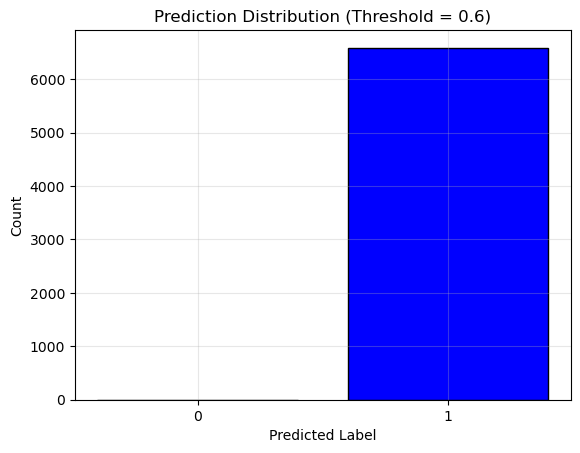

In [20]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt

train_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Assignment3_Train_Resampled.csv'
unknown_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Assignment3_Unknown_Preprocessed.csv'
output_path = '/Users/seungwookim/Desktop/UTS/Year 2/Introduction to Data Analytics/Assignment 3/Python/Kaggle_Submission_SVM.csv'

train_df = pd.read_csv(train_path)
unknown_df = pd.read_csv(unknown_path)

X_train = train_df.drop(columns=['subscribed'])
y_train = train_df['subscribed']

row_ids = unknown_df['row ID']
X_unknown = unknown_df.drop(columns=['row ID'])

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_unknown_scaled = scaler.transform(X_unknown)

def plot_class_distribution(y, title):
    class_counts = Counter(y)
    plt.bar(class_counts.keys(), class_counts.values(), color='blue', alpha=0.7)
    plt.xticks([0, 1])
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()

class_counts = Counter(y_train)
majority_count = class_counts[0]
minority_count = class_counts[1]
minority_ratio = minority_count / (majority_count + minority_count)

rus_ratio = {0: minority_count * 2, 1: minority_count}

try:
    rus = RandomUnderSampler(sampling_strategy=rus_ratio, random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train_scaled, y_train)
    plot_class_distribution(y_resampled, "Under-Sampling Distribution")
except ValueError as e:
    print(f"Under-Sampling error: {e}")
    X_resampled, y_resampled = X_train_scaled, y_train

smote_ratio = 0.25
print(f"SMOTE: {smote_ratio}")

try:
    smote = SMOTE(sampling_strategy=smote_ratio, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_resampled, y_resampled)
    plot_class_distribution(y_resampled, "SMOTE Distribution")
except ValueError as e:
    print(f"error: {e}")
    X_resampled, y_resampled = X_train_scaled, y_train

svm_model = SVC(
    C=1.0,
    kernel='rbf',
    gamma=0.001,
    probability=True,
    random_state=42
)

svm_model.fit(X_resampled, y_resampled)
y_proba = svm_model.decision_function(X_unknown_scaled)
optimal_threshold = 0.6

for threshold in np.arange(0.6, 0.91, 0.05):
    y_pred = (y_proba >= threshold).astype(int)
    positive_rate = y_pred.sum() / len(y_pred)

    print(f"Threshold: {threshold:.2f} - Positive Rate: {positive_rate:.2f}")

    if 0.1 <= positive_rate <= 0.25:
        optimal_threshold = threshold
        break

print(f"Final Threshold: {optimal_threshold}")

y_pred_final = (y_proba >= optimal_threshold).astype(int)

plt.hist(y_pred_final, bins=[-0.5, 0.5, 1.5], rwidth=0.8, color='blue', edgecolor='black')
plt.xticks([0, 1])
plt.title(f"Prediction Distribution (Threshold = {optimal_threshold})")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

submission = pd.DataFrame({'row ID': row_ids, 'Prediction-subscribed': y_pred_final})
submission.to_csv(output_path, index=False)